# SID Quality Heuristics

Notebook for quick, heuristic checks of Semantic ID interpretability.

Main idea: we do not validate final recommender quality here. We only ask whether SID prefixes form reasonably interpretable groups under MovieLens genres.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


In [2]:
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

SID_PATH = ROOT / "runs/qwen4b_rqvae_sid_v2_plum/sid_mapping_best.parquet"
PROFILE_PATH = ROOT / "data/processed/item_features/qwen4b_audited_v1_item_profiles.parquet"
SUMMARY_PATH = ROOT / "runs/qwen4b_rqvae_sid_v2_plum/summary.json"
OUT_DIR = ROOT / "reports/assets"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SID_COLS = ["sid_0", "sid_1", "sid_2", "sid_3"]

print(ROOT)
print(SID_PATH.exists(), SID_PATH)
print(PROFILE_PATH.exists(), PROFILE_PATH)


C:\Users\User\plum-ml1m-repro
True C:\Users\User\plum-ml1m-repro\runs\qwen4b_rqvae_sid_v2_plum\sid_mapping_best.parquet
True C:\Users\User\plum-ml1m-repro\data\processed\item_features\qwen4b_audited_v1_item_profiles.parquet


## 1. Load SID mapping and movie metadata

We merge the best RQ-VAE SID mapping with the audited item profiles. Genres are multi-label, so the genre analysis below works on an exploded table: one row per `(movie, genre)`.


In [3]:
sid = pd.read_parquet(SID_PATH)
profiles = pd.read_parquet(PROFILE_PATH)

meta_cols = ["item_idx", "movie_id", "title", "year", "genres", "genres_text", "overview"]
df = (
    sid.merge(profiles[meta_cols], on=["item_idx", "movie_id"], how="left", validate="one_to_one")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

for depth in range(1, 5):
    cols = SID_COLS[:depth]
    df[f"sid_d{depth}"] = df[cols].apply(lambda r: tuple(int(v) for v in r), axis=1)
    df[f"sid_d{depth}_label"] = df[f"sid_d{depth}"].map(
        lambda x: "(" + ", ".join(map(str, x)) + (", *" if len(x) < 4 else "") + ")"
    )

def split_genres(value):
    return [g.strip() for g in str(value).split("|") if g.strip() and g.strip() != "nan"]

genre_long = df.assign(genre=df["genres"].map(split_genres)).explode("genre")
genre_long = genre_long[genre_long["genre"].notna()].reset_index(drop=True)

print(df.shape, genre_long.shape)
df[["item_idx", "movie_id", "title", "genres", *SID_COLS]].head()


(3706, 19) (6194, 20)


,item_idx,movie_id,title,genres,sid_0,sid_1,sid_2,sid_3
0,0,1,Toy Story (1995),Animation|Children's|Comedy,32,134,20,18
1,1,2,Jumanji (1995),Adventure|Children's|Fantasy,469,18,69,31
2,2,3,Grumpier Old Men (1995),Comedy|Romance,284,173,2,12
3,3,4,Waiting to Exhale (1995),Comedy|Drama,461,0,33,48
4,4,5,Father of the Bride Part II (1995),Comedy,284,147,94,63


In [4]:
genre_counts = genre_long["genre"].value_counts().rename_axis("genre").reset_index(name="n_assignments")
item_counts = df[["item_idx"]].shape[0]

print("items:", item_counts)
print("genre assignments:", len(genre_long))
genre_counts


items: 3706
genre assignments: 6194


,genre,n_assignments
0,Drama,1493
1,Comedy,1164
2,Action,495
3,Thriller,485
4,Romance,459
5,Horror,339
6,Adventure,281
7,Sci-Fi,274
8,Children's,250
9,Crime,202


## 2. Genre -> first-level SID prefix

This is the closest analogue to the reference plot. For every genre, we estimate `P(sid_0 | genre)`: among movies tagged with this genre, what fraction falls into each large first-level SID bucket.

A good sign is not perfect separation, because MovieLens genres are broad and multi-label, but visible concentration patterns are useful: for example, animation/children/fantasy should not be uniformly scattered across all prefixes.


C:\Users\User\plum-ml1m-repro\reports\assets\sid_quality_genre_to_prefix_d1.png


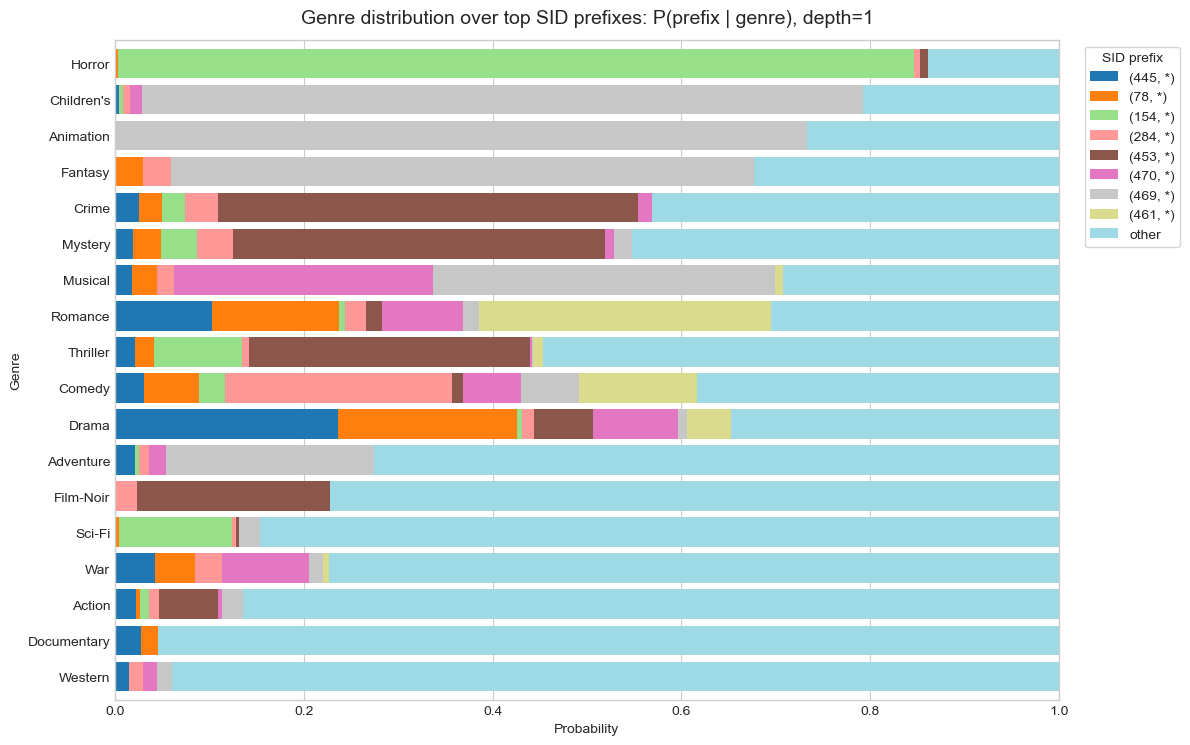

In [5]:
def plot_genre_to_prefix(depth=1, top_prefixes=8, min_prefix_items=20, save=True):
    prefix_col = f"sid_d{depth}_label"
    sizes = df[prefix_col].value_counts()
    selected = sizes[sizes >= min_prefix_items].head(top_prefixes).index.tolist()

    table = pd.crosstab(genre_long["genre"], genre_long[prefix_col], normalize="index")
    plot_df = table.reindex(columns=selected, fill_value=0.0)
    plot_df["other"] = (1.0 - plot_df.sum(axis=1)).clip(lower=0.0)
    plot_df = plot_df.loc[plot_df[selected].max(axis=1).sort_values().index]

    fig_h = max(6, 0.42 * len(plot_df))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    colors = plt.cm.tab20(np.linspace(0, 1, len(plot_df.columns)))
    plot_df.plot(kind="barh", stacked=True, ax=ax, color=colors, width=0.82)

    ax.set_title(f"Genre distribution over top SID prefixes: P(prefix | genre), depth={depth}", fontsize=14, pad=12)
    ax.set_xlabel("Probability")
    ax.set_ylabel("Genre")
    ax.set_xlim(0, 1)
    ax.legend(title="SID prefix", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    fig.tight_layout()

    if save:
        path = OUT_DIR / f"sid_quality_genre_to_prefix_d{depth}.png"
        fig.savefig(path, dpi=160, bbox_inches="tight")
        print(path)
    return plot_df

genre_to_sid0 = plot_genre_to_prefix(depth=1, top_prefixes=8, min_prefix_items=20)


## 3. SID prefix -> genre, combined view

This plot is closer to the reference picture: each color is one selected SID prefix, and each bar value is `P(genre | SID prefix)`. The selected prefixes are the largest first-level SID buckets.


C:\Users\User\plum-ml1m-repro\reports\assets\sid_quality_prefix_to_genre_grouped_d1.png


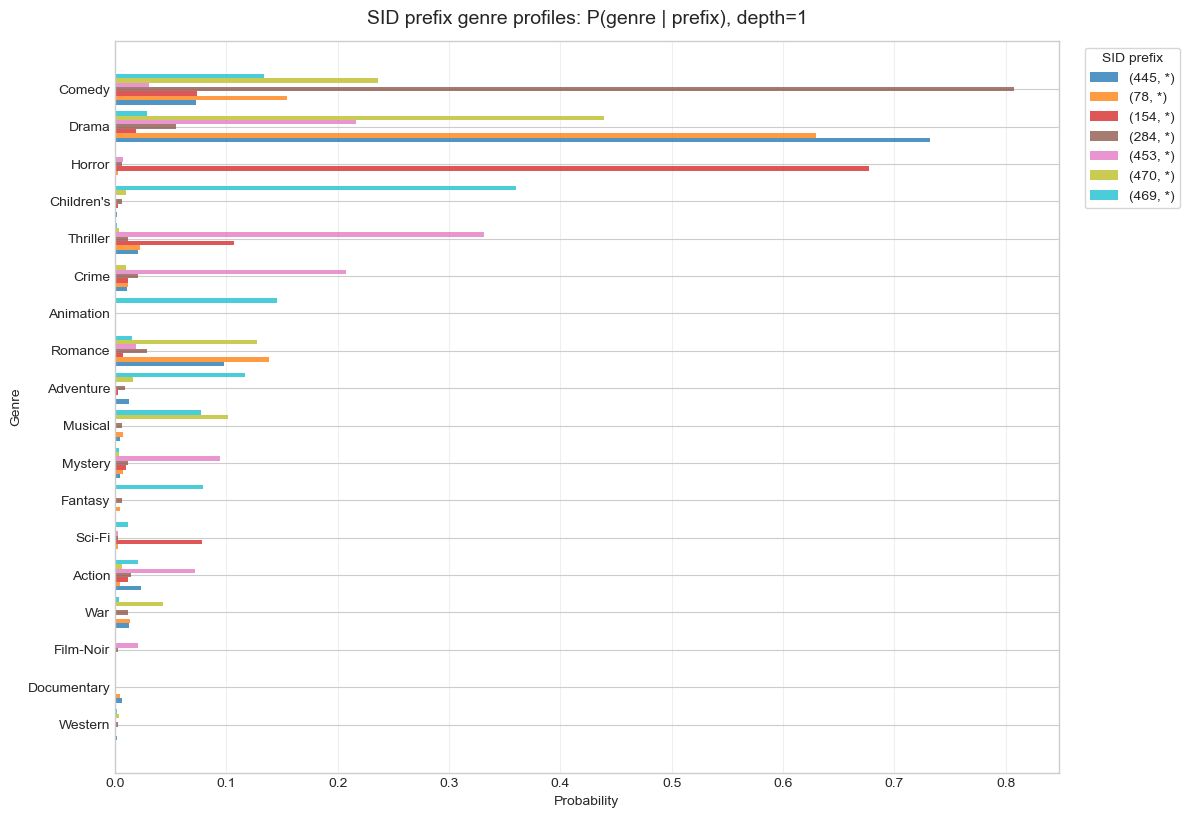

In [6]:
def plot_prefix_to_genre_grouped(depth=1, top_prefixes=7, min_prefix_items=20, save=True):
    prefix_col = f"sid_d{depth}_label"
    selected = df[prefix_col].value_counts().loc[lambda s: s >= min_prefix_items].head(top_prefixes).index.tolist()

    rows = []
    for prefix in selected:
        sub = genre_long[genre_long[prefix_col] == prefix]
        dist = sub["genre"].value_counts(normalize=True)
        rows.append(dist.rename(prefix))

    table = pd.concat(rows, axis=1).fillna(0.0)
    table = table.loc[table.max(axis=1).sort_values().index]

    y = np.arange(len(table.index))
    bar_h = 0.82 / max(1, len(selected))
    offsets = (np.arange(len(selected)) - (len(selected) - 1) / 2) * bar_h

    fig, ax = plt.subplots(figsize=(12, max(6, 0.46 * len(table))))
    colors = plt.cm.tab10(np.linspace(0, 1, len(selected)))
    for j, prefix in enumerate(selected):
        ax.barh(y + offsets[j], table[prefix].values, height=bar_h, label=prefix, color=colors[j], alpha=0.78)

    ax.set_yticks(y)
    ax.set_yticklabels(table.index)
    ax.set_xlabel("Probability")
    ax.set_ylabel("Genre")
    ax.set_title(f"SID prefix genre profiles: P(genre | prefix), depth={depth}", fontsize=14, pad=12)
    ax.legend(title="SID prefix", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()

    if save:
        path = OUT_DIR / f"sid_quality_prefix_to_genre_grouped_d{depth}.png"
        fig.savefig(path, dpi=160, bbox_inches="tight")
        print(path)
    return table

prefix_to_genre_sid0 = plot_prefix_to_genre_grouped(depth=1, top_prefixes=7, min_prefix_items=20)


## 4. SID prefix -> genre profile

Now we invert the question and estimate `P(genre | SID prefix)`. Each small panel is one SID prefix. This is easier to read as cluster interpretability: if the top genres are coherent, the prefix has semantic meaning.


C:\Users\User\plum-ml1m-repro\reports\assets\sid_quality_prefix_genre_profiles_d1_largest.png


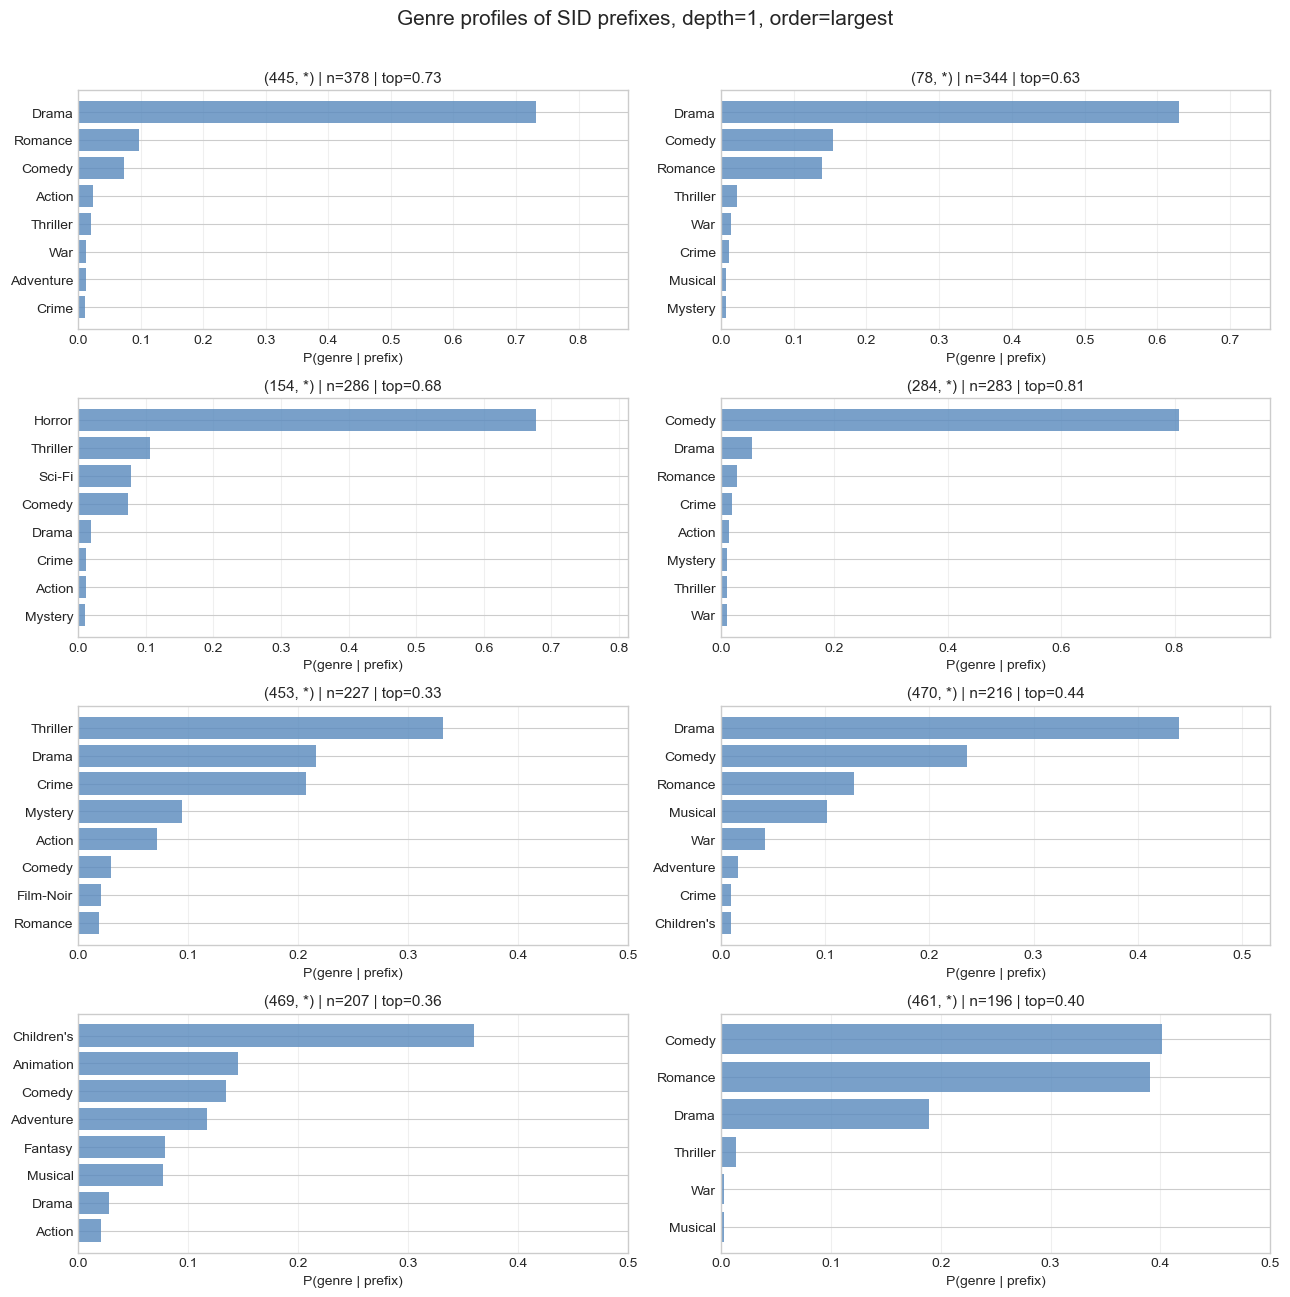

In [7]:
def prefix_purity_table(depth=1, min_items=10):
    prefix_col = f"sid_d{depth}_label"
    size = df.groupby(prefix_col)["item_idx"].nunique().rename("n_items")
    counts = genre_long.groupby([prefix_col, "genre"]).size().rename("n").reset_index()
    totals = counts.groupby(prefix_col)["n"].sum().rename("n_genre_assignments")
    top = counts.sort_values("n", ascending=False).groupby(prefix_col).head(1)

    out = (
        top.merge(size, left_on=prefix_col, right_index=True)
        .merge(totals, left_on=prefix_col, right_index=True)
        .assign(top_genre_prob=lambda x: x["n"] / x["n_genre_assignments"])
        .rename(columns={"genre": "top_genre"})
        [[prefix_col, "n_items", "top_genre", "top_genre_prob", "n_genre_assignments"]]
        .query("n_items >= @min_items")
        .sort_values(["top_genre_prob", "n_items"], ascending=[False, False])
        .reset_index(drop=True)
    )
    return out

def plot_prefix_genre_panels(depth=1, n_prefixes=6, top_genres=8, min_items=25, order="largest", save=True):
    prefix_col = f"sid_d{depth}_label"
    if order == "pure":
        selected = prefix_purity_table(depth, min_items).head(n_prefixes)[prefix_col].tolist()
    else:
        selected = df[prefix_col].value_counts().loc[lambda s: s >= min_items].head(n_prefixes).index.tolist()

    ncols = 2
    nrows = math.ceil(len(selected) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, prefix in zip(axes, selected):
        sub = genre_long[genre_long[prefix_col] == prefix]
        dist = sub["genre"].value_counts(normalize=True).head(top_genres).sort_values()
        n_items = df.loc[df[prefix_col] == prefix, "item_idx"].nunique()
        purity = dist.max() if len(dist) else 0.0

        ax.barh(dist.index, dist.values, color="#5B8BBE", alpha=0.82)
        ax.set_title(f"{prefix} | n={n_items} | top={purity:.2f}", fontsize=11)
        ax.set_xlabel("P(genre | prefix)")
        ax.set_xlim(0, max(0.5, min(1.0, dist.max() * 1.2 if len(dist) else 0.5)))
        ax.grid(axis="x", alpha=0.3)

    for ax in axes[len(selected):]:
        ax.axis("off")

    fig.suptitle(f"Genre profiles of SID prefixes, depth={depth}, order={order}", fontsize=15, y=1.01)
    fig.tight_layout()

    if save:
        path = OUT_DIR / f"sid_quality_prefix_genre_profiles_d{depth}_{order}.png"
        fig.savefig(path, dpi=160, bbox_inches="tight")
        print(path)
    return selected

largest_sid0 = plot_prefix_genre_panels(depth=1, n_prefixes=8, min_items=25, order="largest")


C:\Users\User\plum-ml1m-repro\reports\assets\sid_quality_prefix_genre_profiles_d2_pure.png


,selected_depth2_prefixes
0,"(154, 98, *)"
1,"(445, 241, *)"
2,"(78, 194, *)"
3,"(284, 240, *)"
4,"(78, 146, *)"
5,"(212, 91, *)"
6,"(470, 102, *)"
7,"(461, 142, *)"


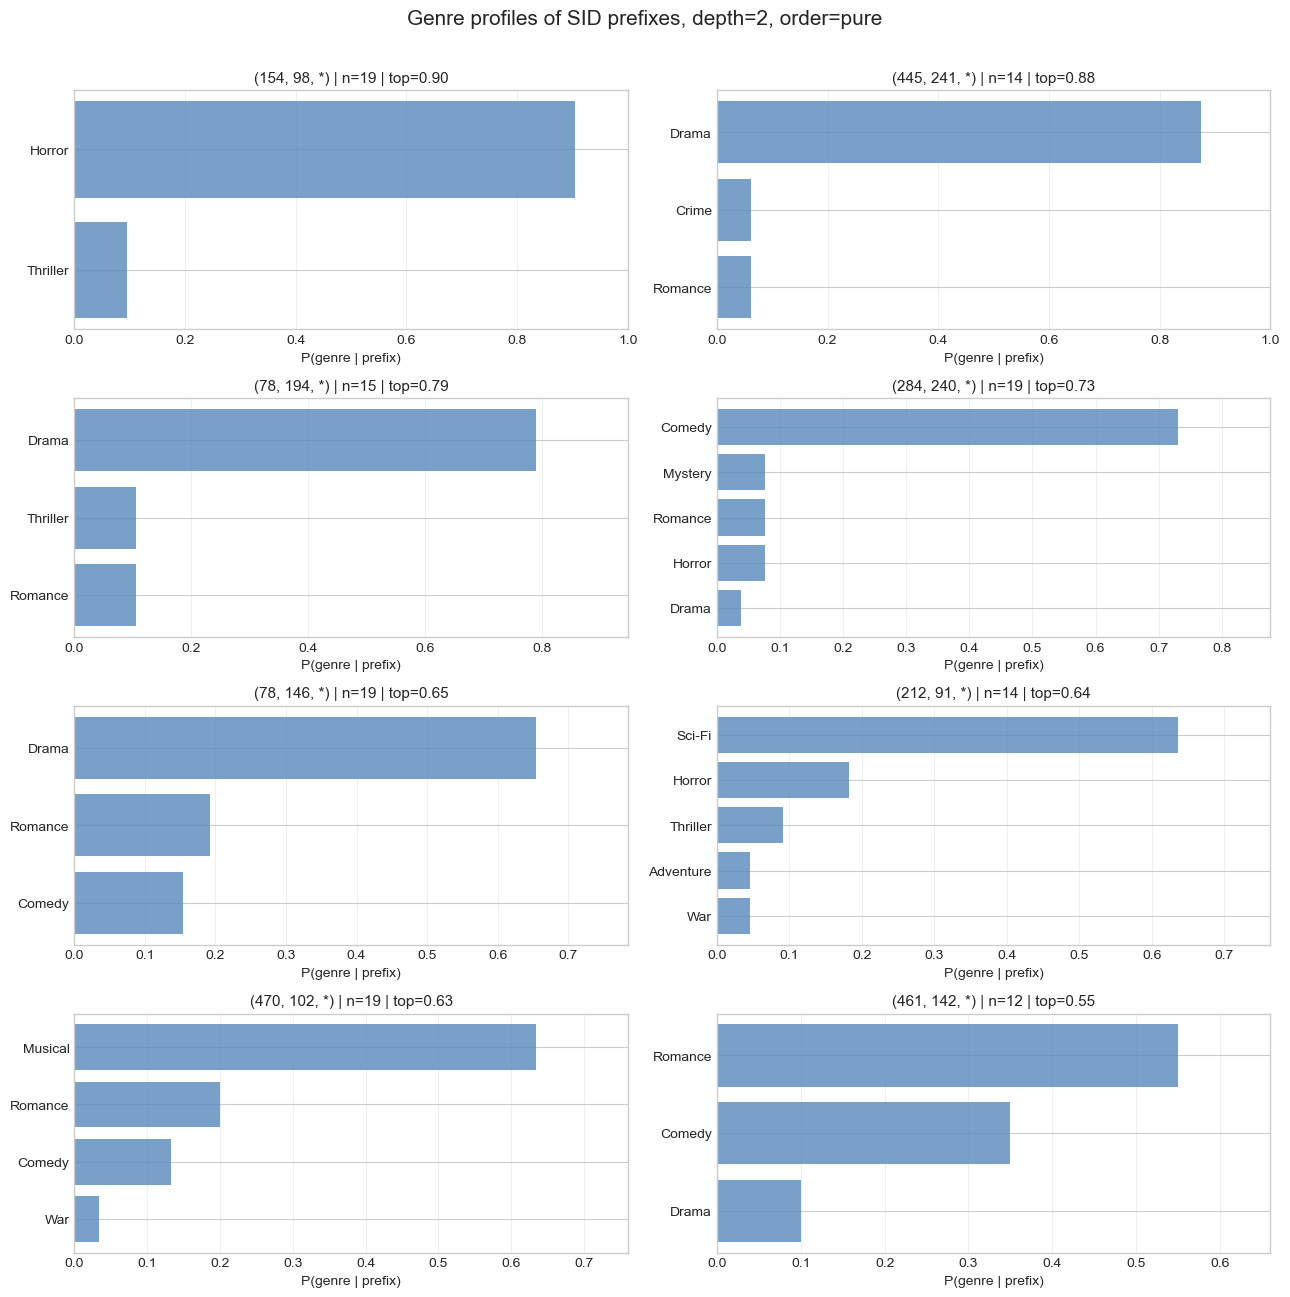

In [8]:
pure_sid2 = plot_prefix_genre_panels(depth=2, n_prefixes=8, min_items=12, order="pure")
pd.DataFrame({"selected_depth2_prefixes": pure_sid2})


## 5. Prefix depth diagnostics

This block compares depths `sid_0`, `(sid_0, sid_1)`, `(sid_0, sid_1, sid_2)`, and full 4-token SID.

Useful heuristics:
- `weighted_purity`: average top-genre share inside a prefix, weighted by cluster size.
- `weighted_entropy_norm`: average normalized genre entropy inside a prefix, weighted by cluster size; lower means cleaner genre composition.
- `unique_prefixes`: how many distinct prefixes exist at this depth.
- `singleton_rate`: how many prefix clusters contain exactly one movie.


In [9]:
ALL_GENRES = sorted(genre_long["genre"].unique())
N_GENRES = len(ALL_GENRES)

def depth_stats(depth):
    prefix_col = f"sid_d{depth}_label"
    item_size = df.groupby(prefix_col)["item_idx"].nunique().rename("n_items")
    counts = genre_long.groupby([prefix_col, "genre"]).size().rename("n").reset_index()
    counts["p"] = counts["n"] / counts.groupby(prefix_col)["n"].transform("sum")

    purity = counts.groupby(prefix_col)["p"].max().rename("purity")
    entropy = counts.assign(plogp=lambda x: -x["p"] * np.log(x["p"])).groupby(prefix_col)["plogp"].sum()
    entropy_norm = (entropy / np.log(N_GENRES)).rename("entropy_norm")

    cluster = pd.concat([item_size, purity, entropy_norm], axis=1).fillna(0)
    weights = cluster["n_items"] / cluster["n_items"].sum()

    return {
        "depth": depth,
        "unique_prefixes": int(cluster.shape[0]),
        "median_cluster_size": float(cluster["n_items"].median()),
        "p90_cluster_size": float(cluster["n_items"].quantile(0.90)),
        "max_cluster_size": int(cluster["n_items"].max()),
        "singleton_rate": float((cluster["n_items"] == 1).mean()),
        "weighted_purity": float((cluster["purity"] * weights).sum()),
        "weighted_entropy_norm": float((cluster["entropy_norm"] * weights).sum()),
    }

summary = pd.DataFrame([depth_stats(d) for d in range(1, 5)])
summary


,depth,unique_prefixes,median_cluster_size,p90_cluster_size,max_cluster_size,singleton_rate,weighted_purity,weighted_entropy_norm
0,1,28,106.5,283.9,378,0.035714,0.536159,0.499507
1,2,1422,2.0,5.0,19,0.417722,0.644289,0.255270
2,3,3498,1.0,1.0,6,0.949400,0.722142,0.146773
3,4,3695,1.0,1.0,2,0.997023,0.726821,0.141829


C:\Users\User\plum-ml1m-repro\reports\assets\sid_quality_depth_summary.png


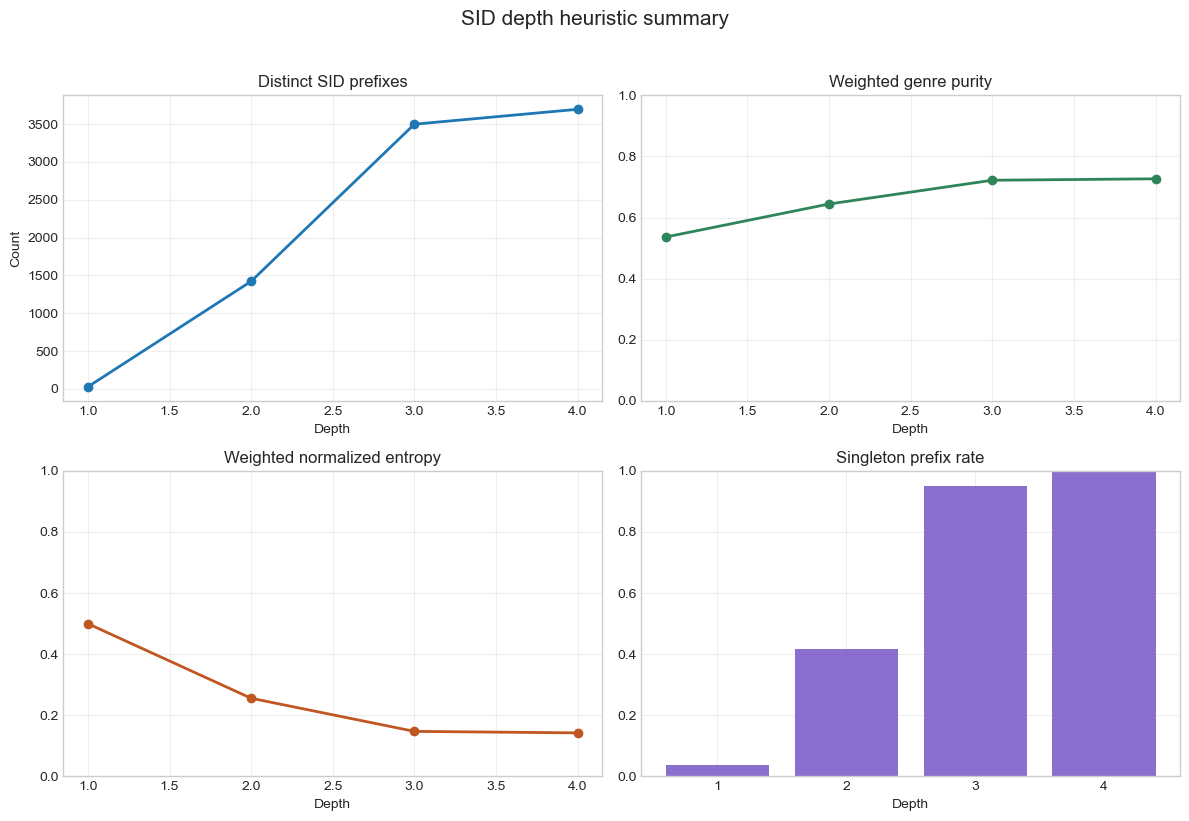

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

axes[0].plot(summary["depth"], summary["unique_prefixes"], marker="o", linewidth=2)
axes[0].set_title("Distinct SID prefixes")
axes[0].set_xlabel("Depth")
axes[0].set_ylabel("Count")

axes[1].plot(summary["depth"], summary["weighted_purity"], marker="o", linewidth=2, color="#2F855A")
axes[1].set_title("Weighted genre purity")
axes[1].set_xlabel("Depth")
axes[1].set_ylim(0, 1)

axes[2].plot(summary["depth"], summary["weighted_entropy_norm"], marker="o", linewidth=2, color="#C05621")
axes[2].set_title("Weighted normalized entropy")
axes[2].set_xlabel("Depth")
axes[2].set_ylim(0, 1)

axes[3].bar(summary["depth"].astype(str), summary["singleton_rate"], color="#6B46C1", alpha=0.78)
axes[3].set_title("Singleton prefix rate")
axes[3].set_xlabel("Depth")
axes[3].set_ylim(0, 1)

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle("SID depth heuristic summary", fontsize=15, y=1.02)
fig.tight_layout()
path = OUT_DIR / "sid_quality_depth_summary.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
print(path)


![SID depth summary](../../reports/assets/sid_quality_depth_summary.png)

## 6. Largest and purest clusters

These tables are useful for manual inspection. Large clusters show the broad first-level partitioning; pure clusters show where deeper SID prefixes become semantically sharp.


In [11]:
largest_tables = []
for depth in range(1, 5):
    prefix_col = f"sid_d{depth}_label"
    part = (
        prefix_purity_table(depth, min_items=1)
        .sort_values("n_items", ascending=False)
        .head(12)
        .assign(depth=depth)
    )
    largest_tables.append(part)

largest_clusters = pd.concat(largest_tables, ignore_index=True)
largest_clusters


,sid_d1_label,n_items,top_genre,top_genre_prob,n_genre_assignments,depth,sid_d2_label,sid_d3_label,sid_d4_label
0,"(445, *)",378,Drama,0.732365,482,1,NaN,NaN,NaN
1,"(78, *)",344,Drama,0.629464,448,1,NaN,NaN,NaN
2,"(154, *)",286,Horror,0.677725,422,1,NaN,NaN,NaN
3,"(284, *)",283,Comedy,0.807471,348,1,NaN,NaN,NaN
4,"(453, *)",227,Thriller,0.331797,434,1,NaN,NaN,NaN
5,"(470, *)",216,Drama,0.439344,305,1,NaN,NaN,NaN
6,"(469, *)",207,Children's,0.360377,530,1,NaN,NaN,NaN
7,"(461, *)",196,Comedy,0.401099,364,1,NaN,NaN,NaN
8,"(212, *)",192,Sci-Fi,0.389002,491,1,NaN,NaN,NaN
9,"(425, *)",189,Action,0.453012,415,1,NaN,NaN,NaN


In [12]:
pure_tables = []
for depth, min_items in [(1, 20), (2, 12), (3, 6), (4, 2)]:
    part = prefix_purity_table(depth, min_items=min_items).head(12).assign(depth=depth, min_items=min_items)
    pure_tables.append(part)

pure_clusters = pd.concat(pure_tables, ignore_index=True)
pure_clusters


,sid_d1_label,n_items,top_genre,top_genre_prob,n_genre_assignments,depth,min_items,sid_d2_label,sid_d3_label,sid_d4_label
0,"(411, *)",105,Documentary,0.895652,115,1,20,NaN,NaN,NaN
1,"(284, *)",283,Comedy,0.807471,348,1,20,NaN,NaN,NaN
2,"(442, *)",142,Drama,0.741935,186,1,20,NaN,NaN,NaN
3,"(445, *)",378,Drama,0.732365,482,1,20,NaN,NaN,NaN
4,"(154, *)",286,Horror,0.677725,422,1,20,NaN,NaN,NaN
5,"(78, *)",344,Drama,0.629464,448,1,20,NaN,NaN,NaN
6,"(148, *)",102,Comedy,0.621951,164,1,20,NaN,NaN,NaN
7,"(109, *)",60,Western,0.600000,100,1,20,NaN,NaN,NaN
8,"(32, *)",67,Comedy,0.567797,118,1,20,NaN,NaN,NaN
9,"(405, *)",77,Comedy,0.463415,123,1,20,NaN,NaN,NaN


## 7. Quick notes

Interpretation rule of thumb:
- Depth 1 should give broad semantic regions, not perfect genres.
- Depth 2-3 should noticeably improve purity while keeping non-trivial cluster sizes.
- Depth 4 is expected to be almost item-level; very high singleton rate is normal and not necessarily bad for SIDs.
- These plots are diagnostic only. The final check is still downstream PLUM-style CPT/SFT recommendation quality.
